In [1]:
import os
import numpy as np
import pandas as pd

In [2]:
os.chdir("/home/wergillius/Project/PINN_dynamics")

# Bash evaluate
evaluate all the u_free model trained on Tom positive cells

```bash
bash tompos_eval.sh > tompos_v0-17_eval.log
```

All evaluattion results are saved to `results/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]`

In [3]:
result_dir = "results/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/pde_u_free_tsense_Dec03_onbase"

In [6]:
perform_files = [file for file in os.listdir(result_dir) if file.endswith("_perform.csv")]

In [8]:
all_df = []
for csv in perform_files:
    path = os.path.join(result_dir, csv)
    version = csv.split("_")[1]
    df = pd.read_csv(path, low_memory=False)
    df['version'] = version
    all_df.append(df)

In [ ]:
all_df = pd.concat(all_df)
all_df = all_df.reindex()

In [19]:
all_df.to_csv(f"{result_dir}/u_free_version0-17.csv", index=False)

In [36]:
import seaborn as sns
from matplotlib import rc_context
import matplotlib.pyplot as plt

In [48]:
# fig, ax = plt.subplots(1,1, figsize=(10,2), dpi=300)
sns.set_theme(font_scale=1.3)
with rc_context({"figure.dpi":300, 'figure.figsize':(4,2)}):
    sns.catplot(data=all_df, col='version', y='KLD', x='timepoints', hue='timepoints',
                     kind='bar', col_wrap=2, sharex=False, sharey=False, aspect=1.6)

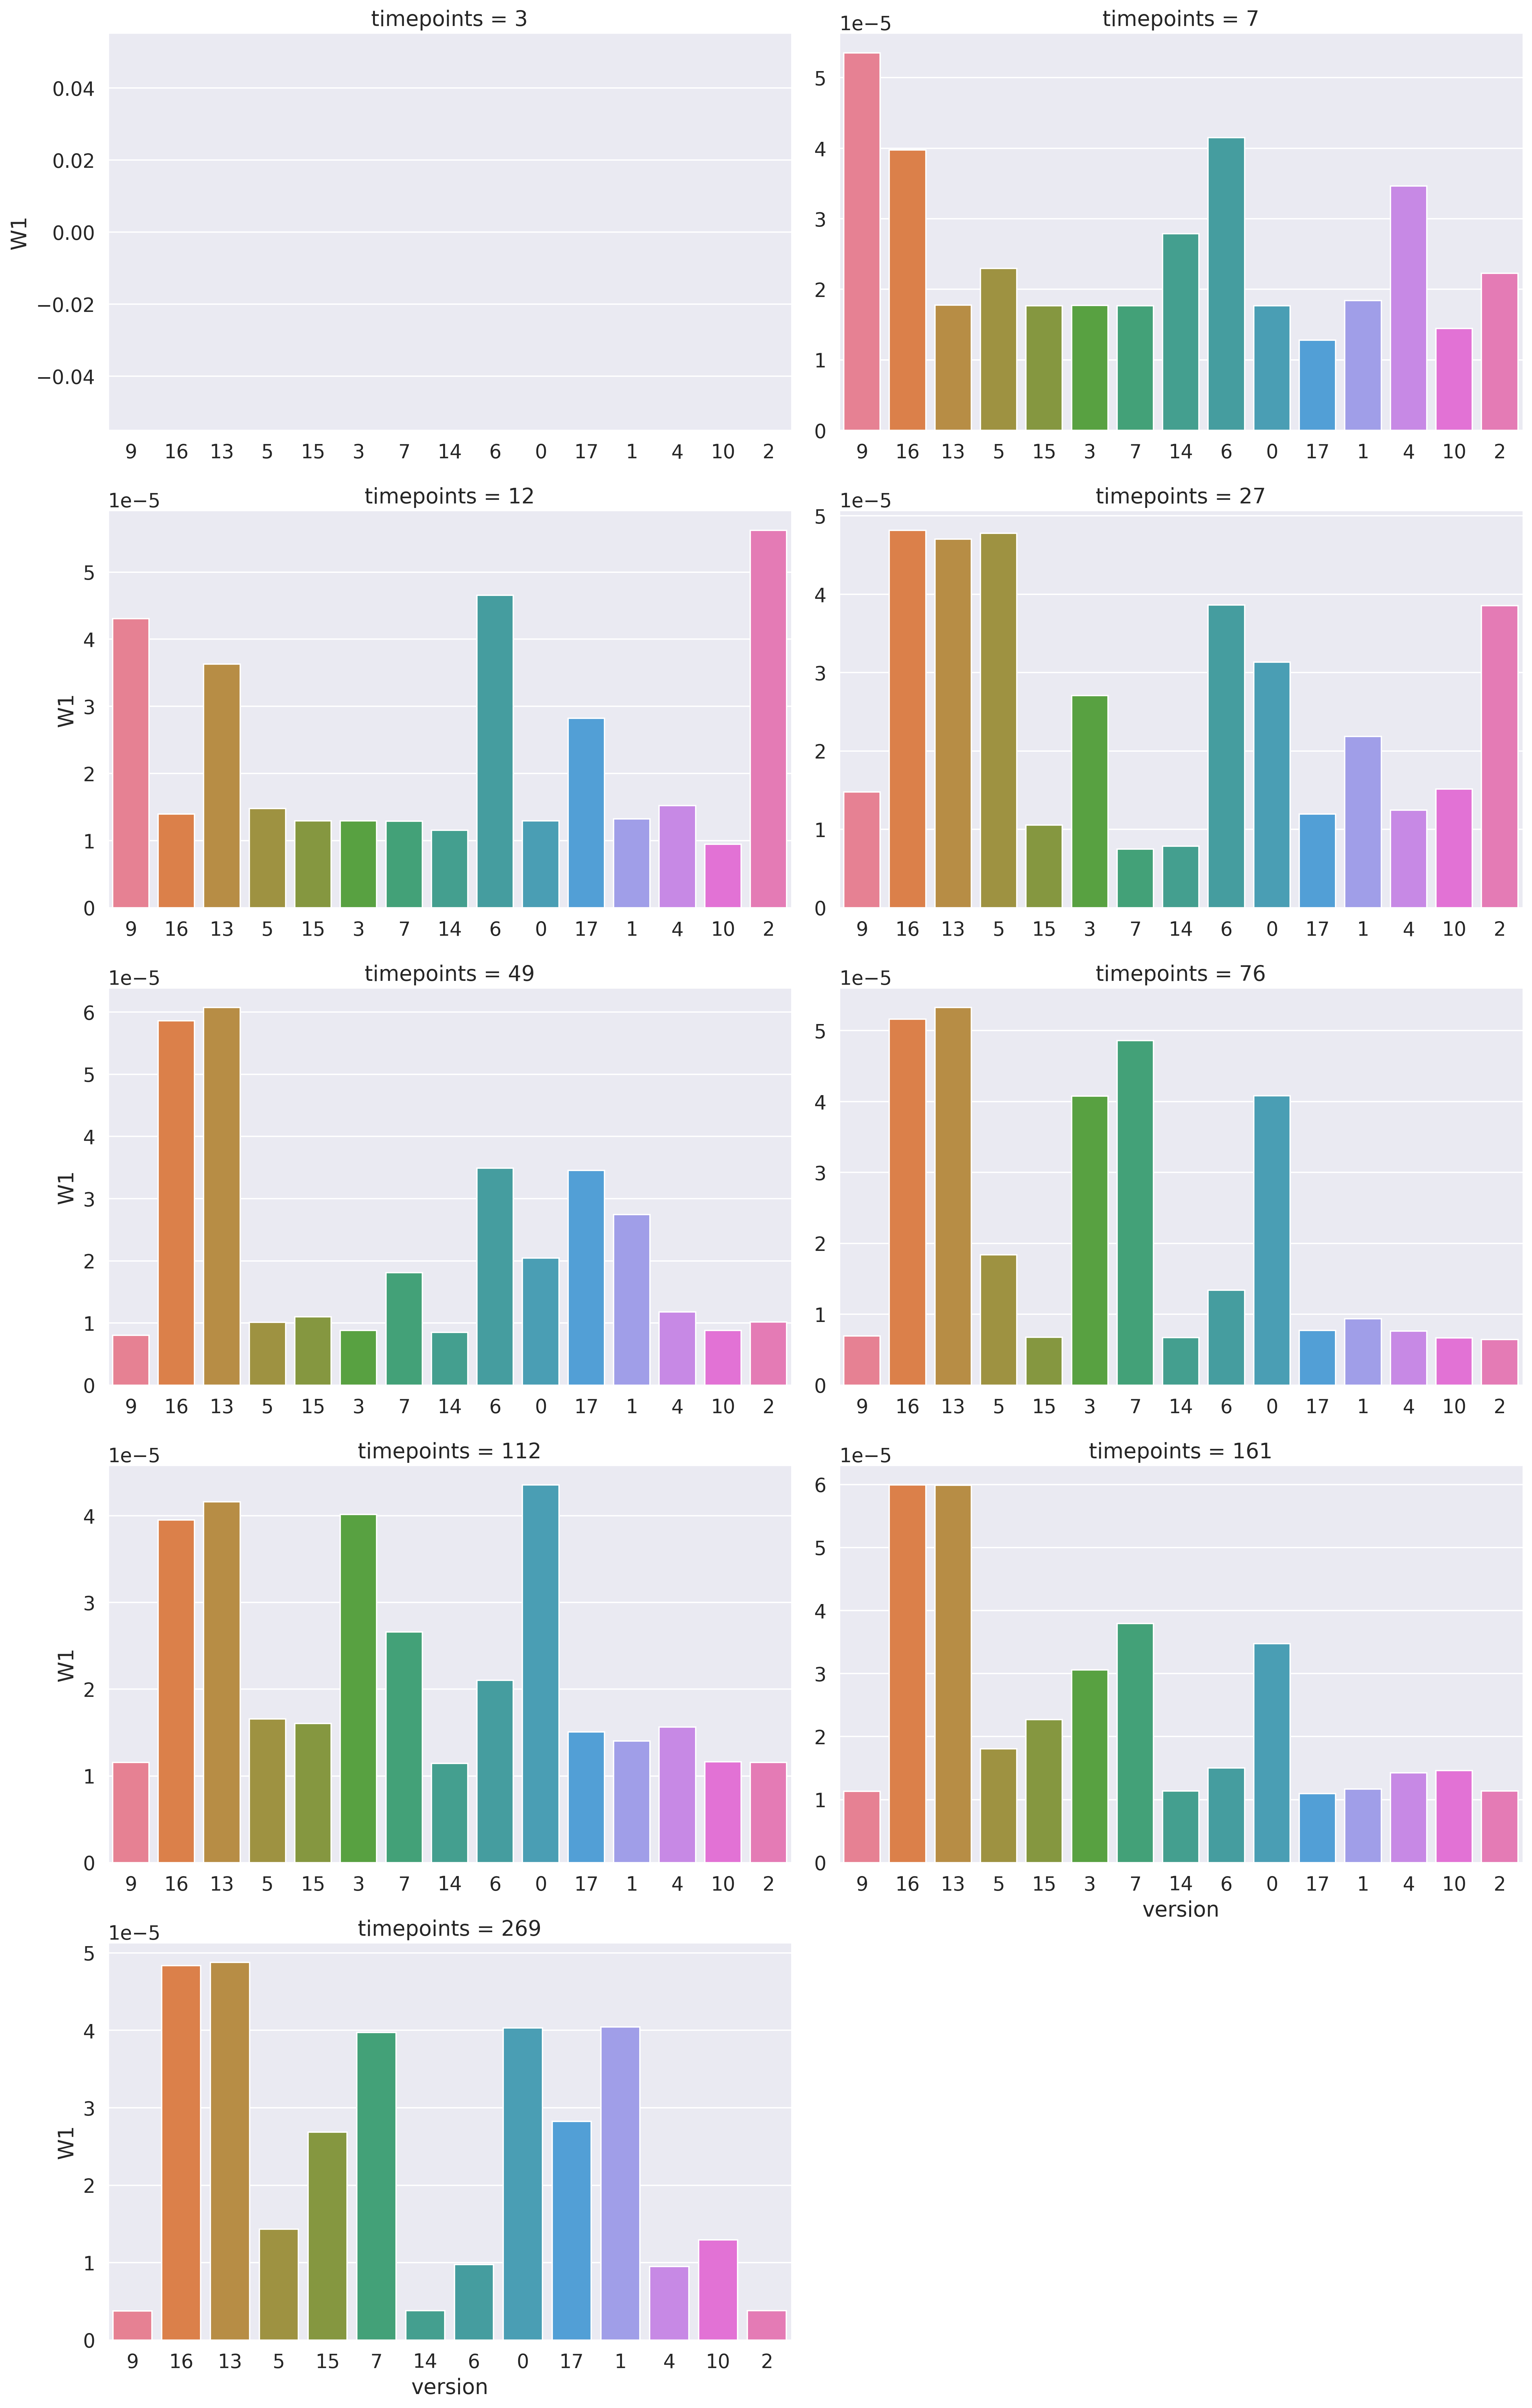

In [47]:
# fig, ax = plt.subplots(1,1, figsize=(10,2), dpi=300)
sns.set_theme(font_scale=1.3)
with rc_context({"figure.dpi":300, 'figure.figsize':(4,2)}):
    sns.catplot(data=all_df, col='timepoints', y='W1', x='version', hue='version',
                     kind='bar', col_wrap=2, sharex=False, sharey=False, aspect=1.6)